# 1.Import Library

In [1]:
import os
import cv2
import time
import pickle
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from skimage.feature import hog

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

np.random.seed(42)
random.seed(42)

# 2. Data Preprocessing

In [2]:
dataset_path = r"C:\Users\ADMIN\Downloads\archive\raw-img"

print(f"Đường dẫn dataset: {dataset_path}")

# List các thư mục trong raw-img
dataset_contents = sorted([d for d in os.listdir(dataset_path) 
                          if os.path.isdir(os.path.join(dataset_path, d))])
print(f"\nTìm thấy {len(dataset_contents)} thư mục trong '{dataset_path}':")
for folder in dataset_contents:
    num_files = len([f for f in os.listdir(os.path.join(dataset_path, folder)) 
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"  {folder:15} - {num_files:4d} files")

Đường dẫn dataset: C:\Users\ADMIN\Downloads\archive\raw-img

Tìm thấy 10 thư mục trong 'C:\Users\ADMIN\Downloads\archive\raw-img':
  cane            - 4863 files
  cavallo         - 2623 files
  elefante        - 1446 files
  farfalla        - 2112 files
  gallina         - 3098 files
  gatto           - 1668 files
  mucca           - 1866 files
  pecora          - 1820 files
  ragno           - 4821 files
  scoiattolo      - 1862 files


In [3]:
translation_table = {
    "cane": "dog",
    "cavallo": "horse", 
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "scoiattolo": "squirrel",
    "ragno": "spider"
}

# Kiểm tra bản dịch
print("Bảng dịch tên thư mục (Italian -> English):")
for ita, eng in translation_table.items():
    print(f"{ita:12} -> {eng}")

Bảng dịch tên thư mục (Italian -> English):
cane         -> dog
cavallo      -> horse
elefante     -> elephant
farfalla     -> butterfly
gallina      -> chicken
gatto        -> cat
mucca        -> cow
pecora       -> sheep
scoiattolo   -> squirrel
ragno        -> spider


In [4]:
def load_dataset(dataset_path, translation_table):

    image_paths = []
    labels = []

    all_folders = os.listdir(dataset_path)

    for label in tqdm(all_folders, desc='Loading folders'):

        label_path = os.path.join(dataset_path, label)

        if os.path.isdir(label_path) and label in translation_table:

            for image_file in os.listdir(label_path):

                if image_file.lower().endswith(('.jpg', '.jpeg', '.png', '.jfif')):

                    image_path = os.path.join(label_path, image_file)

                    if os.path.isfile(image_path):

                        image_paths.append(image_path)
                        labels.append(translation_table[label])

    df = pd.DataFrame({
        'image_path': image_paths,
        'label': labels
    })

    print(f"\n✓ Loaded {len(df)} images")

    print(df['label'].value_counts())

    return df


data = load_dataset(dataset_path, translation_table)

print("\nPreview:")
print(data.head())

Loading folders: 100%|██████████| 10/10 [00:01<00:00,  6.20it/s]


✓ Loaded 26179 images
label
dog          4863
spider       4821
chicken      3098
horse        2623
butterfly    2112
cow          1866
squirrel     1862
sheep        1820
cat          1668
elephant     1446
Name: count, dtype: int64

Preview:
                                          image_path label
0  C:\Users\ADMIN\Downloads\archive\raw-img\cane\...   dog
1  C:\Users\ADMIN\Downloads\archive\raw-img\cane\...   dog
2  C:\Users\ADMIN\Downloads\archive\raw-img\cane\...   dog
3  C:\Users\ADMIN\Downloads\archive\raw-img\cane\...   dog
4  C:\Users\ADMIN\Downloads\archive\raw-img\cane\...   dog


In [7]:
encoder_path = r"C:\Users\ADMIN\CS231\modules\hog_label_encoder.pkl"

os.makedirs(os.path.dirname(encoder_path), exist_ok=True)

if not os.path.exists(encoder_path):

    encoder = LabelEncoder()
    data["label_encoded"] = encoder.fit_transform(data["label"])

    with open(encoder_path, 'wb') as f:
        pickle.dump(encoder, f)

    print("✓ LabelEncoder saved")

else:

    with open(encoder_path, 'rb') as f:
        encoder = pickle.load(f)

    data["label_encoded"] = encoder.transform(data["label"])

    print("✓ LabelEncoder loaded")

print("\nClass Mapping:")
for i, cls in enumerate(encoder.classes_):
    print(f"{cls} → {i}")

✓ LabelEncoder loaded

Class Mapping:
butterfly → 0
cat → 1
chicken → 2
cow → 3
dog → 4
elephant → 5
horse → 6
sheep → 7
spider → 8
squirrel → 9


# 3. Feature Extraction (HOG)

In [6]:
def extract_hog_features(image_paths, target_size=(128, 128)):

    features = []
    failed_images = []

    print(f"\nExtracting HOG from {len(image_paths)} images...")

    orientations = 9
    pixels_per_cell = (8, 8)
    cells_per_block = (2, 2)

    for img_path in tqdm(image_paths):

        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                failed_images.append(img_path)
                continue

            img = cv2.resize(img, target_size)

            hog_features = hog(
                img,
                orientations=orientations,
                pixels_per_cell=pixels_per_cell,
                cells_per_block=cells_per_block,
                block_norm='L2-Hys',
                transform_sqrt=True,
                feature_vector=True
            )

            features.append(hog_features)

        except:
            failed_images.append(img_path)

    print(f"\n✓ Success: {len(features)}")
    print(f"⚠ Failed: {len(failed_images)}")

    return np.array(features)

In [10]:
import os
import pickle

hog_filename = r"C:\Users\ADMIN\CS231\modules\hog_features.pkl"
os.makedirs(os.path.dirname(hog_filename), exist_ok=True)

if not os.path.exists(hog_filename):

    print("\nExtracting HOG features...")
    features = extract_hog_features(data['image_path'])

    with open(hog_filename, 'wb') as f:
        pickle.dump(features, f)

    print(f"✓ Saved to {hog_filename}")

else:

    with open(hog_filename, 'rb') as f:
        features = pickle.load(f)

    print(f"✓ Loaded features: {features.shape}")

✓ Loaded features: (26179, 8100)


#  4. Feature Reduction

In [ ]:
# Feature Scaling
X = features
y = data["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_test.shape)

scaler_path = r"C:\Users\ADMIN\CS231\modules\hog_scaler.pkl"

os.makedirs(os.path.dirname(scaler_path), exist_ok=True)

if not os.path.exists(scaler_path):

    scaler = StandardScaler()
    scaler.fit(X_train)

    with open(scaler_path, "wb") as f:
        pickle.dump(scaler, f)

    print(f"✓ Scaler saved to {scaler_path}")

else:

    with open(scaler_path, "rb") as f:
        scaler = pickle.load(f)

    print(f"✓ Loaded scaler from {scaler_path}")

# transform data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Data scaled successfully")
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(20943, 8100) (5236, 8100)
✓ Loaded scaler from C:\Users\ADMIN\CS231\modules\hog_scaler.pkl

✓ Data scaled successfully
(20943, 8100)
(5236, 8100)


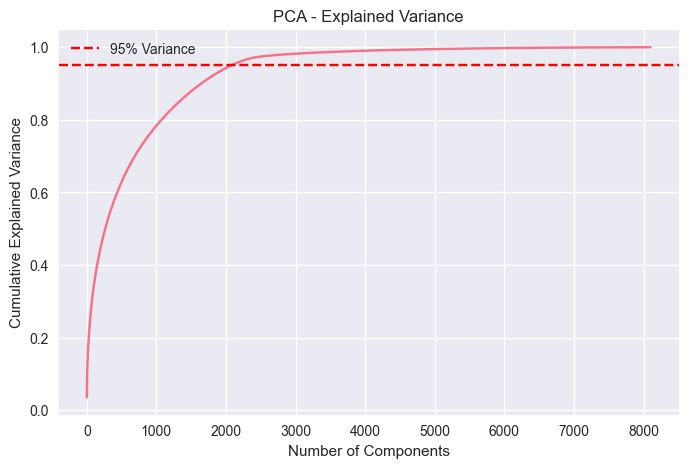

In [9]:
pca = PCA().fit(X_train_scaled)

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.legend()
plt.title('PCA - Explained Variance')
plt.show()

In [12]:
pca_path = r"C:\Users\ADMIN\CS231\modules\hog_pca.pkl"
os.makedirs(os.path.dirname(pca_path), exist_ok=True)
pca_full = PCA().fit(X_train_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cum_var >= 0.95) + 1

print(f"Selected components: {n_components}")

if not os.path.exists(pca_path):

    print("\nTraining PCA...")

    pca = PCA(n_components=n_components)

    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    with open(pca_path, "wb") as f:
        pickle.dump(pca, f)

    print(f"✓ PCA saved to {pca_path}")

else:

    print("\nLoading PCA...")

    with open(pca_path, "rb") as f:
        pca = pickle.load(f)

    X_train_pca = pca.transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    print(f"✓ PCA loaded from {pca_path}")

print("\nPCA Shapes:")
print(f"Train: {X_train_pca.shape}")
print(f"Test : {X_test_pca.shape}")

print(f"\nExplained variance: {pca.explained_variance_ratio_.sum():.4f}")

Selected components: 2076

Loading PCA...
✓ PCA loaded from C:\Users\ADMIN\CS231\modules\hog_pca.pkl

PCA Shapes:
Train: (20943, 2076)
Test : (5236, 2076)

Explained variance: 0.9489


# 5. Classifier

### Random Forest

Training trên 20943 mẫu...
Số lượng parameter combinations: 8
Số folds: 2
Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation score: 0.3326
✓ Random Forest model saved to 'C:\Users\ADMIN\CS231.Q11\modules\hog_random_forest_model.pkl'

Random Forest Test Accuracy: 0.3608

Classification Report - Random Forest:
              precision    recall  f1-score   support

   butterfly       0.97      0.08      0.14       422
         cat       1.00      0.01      0.01       334
     chicken       0.41      0.42      0.42       620
         cow       1.00      0.07      0.13       373
         dog       0.27      0.71      0.40       973
    elephant       1.00      0.04      0.08       289
       horse       0.70      0.21      0.32       525
       sheep       0.88      0.10      0.17       364
      spider       0.39      0.73      0.51       964
    squirrel       0.94      0.04   

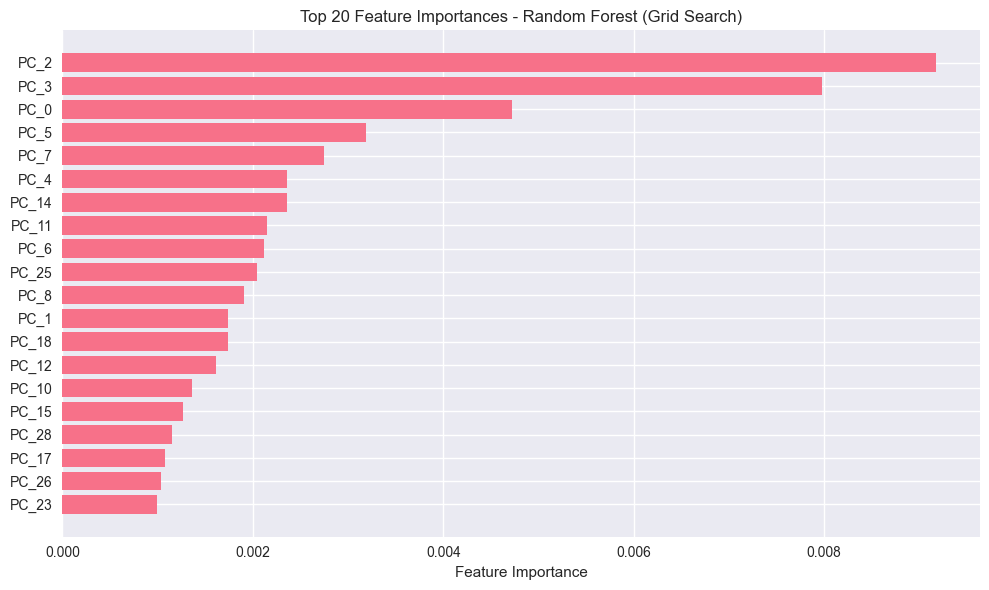


✓ Các biến đã được khởi tạo:
  - rf_accuracy: 0.3608
  - rf_grid: GridSearchCV object
  - best_rf: RandomForestClassifier object
  - y_pred_rf: predictions array (5236 samples)


In [ ]:
from sklearn.ensemble import RandomForestClassifier


rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5]
}

# Tạo Random Forest model
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

# Grid Search với cross-validation
rf_grid = GridSearchCV(
    rf_model, 
    rf_param_grid, 
    cv=2,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)


rf_filename = r"C:\Users\ADMIN\CS231\modules\hog_random_forest_model.pkl"

os.makedirs(os.path.dirname(rf_filename), exist_ok=True)

if os.path.exists(rf_filename):

    print(f"Loading model from: {rf_filename}")

    with open(rf_filename, 'rb') as f:
        best_rf = pickle.load(f)

else:

    # Fit Grid Search trên training set
    print(f"Training trên {len(X_train_pca)} mẫu...")
    
    print(
        f"Số lượng parameter combinations: "
        f"{len(rf_param_grid['n_estimators']) * len(rf_param_grid['max_depth']) * len(rf_param_grid['min_samples_split'])}"
    )

    print(f"Số folds: 2")

    rf_grid.fit(X_train_pca, y_train)

    print(f"Best parameters: {rf_grid.best_params_}")
    print(f"Best cross-validation score: {rf_grid.best_score_:.4f}")

    # Lấy best model
    best_rf = rf_grid.best_estimator_

    # Save model
    with open(rf_filename, 'wb') as f:
        pickle.dump(best_rf, f)

    print(f"✓ Random Forest model saved to '{rf_filename}'")


y_pred_rf = best_rf.predict(X_test_pca)

# Đánh giá model
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"\nRandom Forest Test Accuracy: {rf_accuracy:.4f}")

# Classification report
print("\nClassification Report - Random Forest:")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=encoder.classes_
    )
)

plt.figure(figsize=(10, 6))
importances = best_rf.feature_importances_
sorted_idx = importances.argsort()[-20:]  # Top 20 features
plt.barh(range(len(sorted_idx)), importances[sorted_idx])
plt.yticks(range(len(sorted_idx)), [f"PC_{i}" for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title("Top 20 Feature Importances - Random Forest (Grid Search)")
plt.tight_layout()
plt.show()

print("\n✓ Các biến đã được khởi tạo:")
print(f"  - rf_accuracy: {rf_accuracy:.4f}")
print(f"  - rf_grid: GridSearchCV object")
print(f"  - best_rf: RandomForestClassifier object")
print(f"  - y_pred_rf: predictions array ({len(y_pred_rf)} samples)")

# 6. Prediction

THỬ NGHIỆM VỚI ẢNH MẪU
Ảnh mẫu: C:\Users\ADMIN\Downloads\archive\raw-img\cane\OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg
True label: dog
Random Forest Prediction: dog


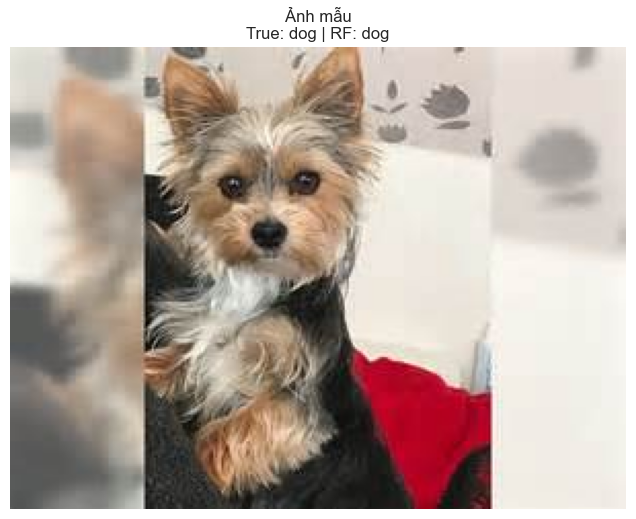

In [14]:
# Cell 15: Thử nghiệm với một ảnh mẫu
print("=" * 60)
print("THỬ NGHIỆM VỚI ẢNH MẪU")
print("=" * 60)

def predict_single_image(image_path, model, scaler, pca, encoder):
    """
    Dự đoán class cho một ảnh đơn lẻ
    """

    try:
        # Đọc ảnh grayscale
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            return None

        # Resize ảnh
        img = cv2.resize(img, (128, 128))

        # Trích xuất HOG features
        hog_features = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            transform_sqrt=True,
            feature_vector=True,
            visualize=False
        )

        # Scale
        hog_features_scaled = scaler.transform([hog_features])

        # PCA
        hog_features_pca = pca.transform(hog_features_scaled)

        # Predict
        prediction_encoded = model.predict(hog_features_pca)[0]

        # Decode label
        prediction_label = encoder.inverse_transform(
            [prediction_encoded]
        )[0]

        return prediction_label

    except Exception as e:

        print(f"Error processing image: {e}")

        return None


# Lấy ảnh mẫu
sample_idx = 0

sample_image_path = data.iloc[sample_idx]['image_path']
true_label = data.iloc[sample_idx]['label']

print(f"Ảnh mẫu: {sample_image_path}")
print(f"True label: {true_label}")

# Predict với Random Forest
rf_prediction = predict_single_image(
    sample_image_path,
    best_rf,
    scaler,
    pca,
    encoder
)

print(f"Random Forest Prediction: {rf_prediction}")

# Hiển thị ảnh
img = cv2.imread(sample_image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))

plt.imshow(img_rgb)

plt.title(
    f"Ảnh mẫu\n"
    f"True: {true_label} | "
    f"RF: {rf_prediction}"
)

plt.axis('off')

plt.show()